# Singapore Government Procurement (GeBIZ) — Audit Analysis

**Question:** using publicly disclosed GeBIZ award data, can we identify supplier concentration, amount-threshold clustering, and Benford's-law deviations that would be worth an auditor's attention?

**Data source:** [data.gov.sg — Government Procurement via GeBIZ](https://data.gov.sg/datasets/d_acde1106003906a75c3fa052592f2fcb/view) (Ministry of Finance), Open Data Licence.

This notebook reproduces the four analyses in the project brief. Data-quality decisions (why each cleaning rule exists) are documented in [`../notes.md`](../notes.md) — this notebook focuses on running the analysis and interpreting results, not re-deriving those decisions.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from cleaning import clean_pipeline
from analysis import (
    aggregate_by_tender,
    concentration_by_group, threshold_window_counts, benford_mad, benford_expected, nigrini_band, benford_by_agency,
    top_suppliers, yearly_trend, agency_year_pivot,
)
from plotting import set_style
set_style()

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

## 1. Load and clean

See `notes.md` for the full data-quality investigation. Summary of what `clean_pipeline` does:
- drops 639 "Awarded to No Suppliers" rows (no real award happened)
- normalizes supplier name punctuation/case/suffix spelling (conservatively — verified it only merges 7 groups, all confirmed true duplicates)
- parses `award_date` and derives Singapore fiscal year (Apr–Mar)

In [2]:
df_raw = pd.read_csv('../data/raw/gebiz_procurement.csv', low_memory=False)
df = clean_pipeline(df_raw)

print(f'raw rows: {len(df_raw):,} -> cleaned rows: {len(df):,}')
print(f'raw distinct suppliers: {df_raw["supplier_name"].nunique():,} -> normalized: {df["supplier_name"].nunique():,}')
df.head(3)

raw rows: 18,464 -> cleaned rows: 17,825
raw distinct suppliers: 6,152 -> normalized: 6,144


,tender_no,tender_description,agency,award_date,tender_detail_status,supplier_name,awarded_amt,supplier_name_raw,fiscal_year,procurement_type
0,ACR000ETT21000001,"DESIGN, DEVELOPMENT, CUSTOMIZATION, DELIVERY, ...",Accounting And Corporate Regulatory Authority,2021-09-06,Awarded to Suppliers,ALPHA ZETTA PTE LTD,2321600.0,ALPHA ZETTA PTE. LTD.,FY2021,ETT
1,ACR000ETT21000003,"SUPPLY, DELIVERY, INSTALLATION, TESTING, COMMI...",Accounting And Corporate Regulatory Authority,2022-04-14,Awarded to Suppliers,ACCENTURE SG SERVICES PTE LTD,108555723.0,ACCENTURE SG SERVICES PTE. LTD.,FY2022,ETT
2,ACR000ETT21000004,INVITATION TO TENDER FOR THE APPLICATION SOFTW...,Accounting And Corporate Regulatory Authority,2022-04-13,Awarded to Suppliers,CRIMSONLOGIC PTE LTD,4503450.0,CRIMSONLOGIC PTE LTD,FY2022,ETT


## 2. Supplier concentration (HHI / CR4)

**Metric choice:** I compute both HHI (sum of squared market shares, 0–10,000) and CR4 (combined share of the top 4 suppliers) — they usually agree, but CR4 is easier to explain to a non-technical stakeholder ("4 firms take X% of spend") while HHI is the more standard antitrust/regulatory benchmark. I report both rather than picking one.

**Unit choice:** concentration is computed **by amount**, not by award count. A supplier that wins one $500M contract and a supplier that wins fifty $10k contracts have very different market power; amount-weighting captures that, count-weighting doesn't. I compute both below to show they can disagree.

**Grouping:** concentration only means something *within* a comparable procurement pool. A whole-of-government HHI conflates a school buying stationery with LTA building an MRT tunnel — so I compute it per agency, not as one national number (confirmed below: the national number is uninformatively close to zero).

In [3]:
df['_all'] = 'Whole of government'
print('Whole-of-government concentration (why a single national number is not useful):')
display(concentration_by_group(df, ['_all'], min_awards=1))

print('\nTop 12 agencies by amount-weighted HHI (min. 10 awards, so single-contract agencies do not dominate the list):')
conc_amount = concentration_by_group(df, ['agency'], min_awards=10)
display(conc_amount.head(12))

df['count1'] = 1
conc_count = concentration_by_group(df, ['agency'], value_col='count1', min_awards=10)
print('\nSame agencies, ranked by COUNT-weighted HHI instead — notice the ranking changes:')
display(conc_count.head(12))

Whole-of-government concentration (why a single national number is not useful):


,_all,hhi,n_suppliers,total,cr4,n_awards
0,Whole of government,69.030525,6144,1.238219e+11,9.080031,17825



Top 12 agencies by amount-weighted HHI (min. 10 awards, so single-contract agencies do not dominate the list):


,agency,hhi,n_suppliers,total,cr4,n_awards
0,Science Centre Board,8314.413739,64,6.323756e+08,95.017787,101
1,Accounting And Corporate Regulatory Authority,8298.080006,10,1.193574e+08,98.208058,11
2,Ministry of Trade & Industry-Ministry Headquarter,8161.330490,28,4.030053e+08,96.130631,29
3,Council for Estate Agencies,7099.052043,20,1.997556e+07,88.660143,29
4,Ministry of National Development-Ministry Head...,6697.771459,34,5.324857e+08,96.393597,37
5,Inland Revenue Authority of Singapore,6331.488682,40,2.269575e+08,90.372851,48
6,Ministry of Finance - Singapore Customs,5429.995862,49,2.628220e+08,86.477903,60
7,Singapore Sports Council (Sport Singapore),5304.860966,208,1.409106e+09,84.696041,251
8,Judiciary-State Courts,5225.109973,10,5.962676e+07,86.150545,12
9,Singapore Medical Council,5120.960179,17,2.708694e+06,93.958675,41



Same agencies, ranked by COUNT-weighted HHI instead — notice the ranking changes:


,agency,hhi,n_suppliers,total,cr4,n_awards
0,Istana,1600.000000,7,10,70.000000,10
1,Ministry of Trade & Industry-Department of Sta...,1280.276817,11,17,58.823529,17
2,Prime Minister's Office-Ministry Headquarter,1220.850480,17,27,51.851852,27
3,Prime Minister's Office-Elections Department,1200.000000,9,10,50.000000,10
4,Judiciary-State Courts,1111.111111,10,12,50.000000,12
5,Accounting And Corporate Regulatory Authority,1074.380165,10,11,45.454545,11
6,Ministry of Manpower - Work Pass Division,1000.000000,10,10,40.000000,10
7,National Environment Agency - ENV19,1000.000000,10,10,40.000000,10
8,Singapore Chinese Girls' School,918.367347,12,14,42.857143,14
9,"School of Science and Technology, Singapore",914.127424,15,19,42.105263,19


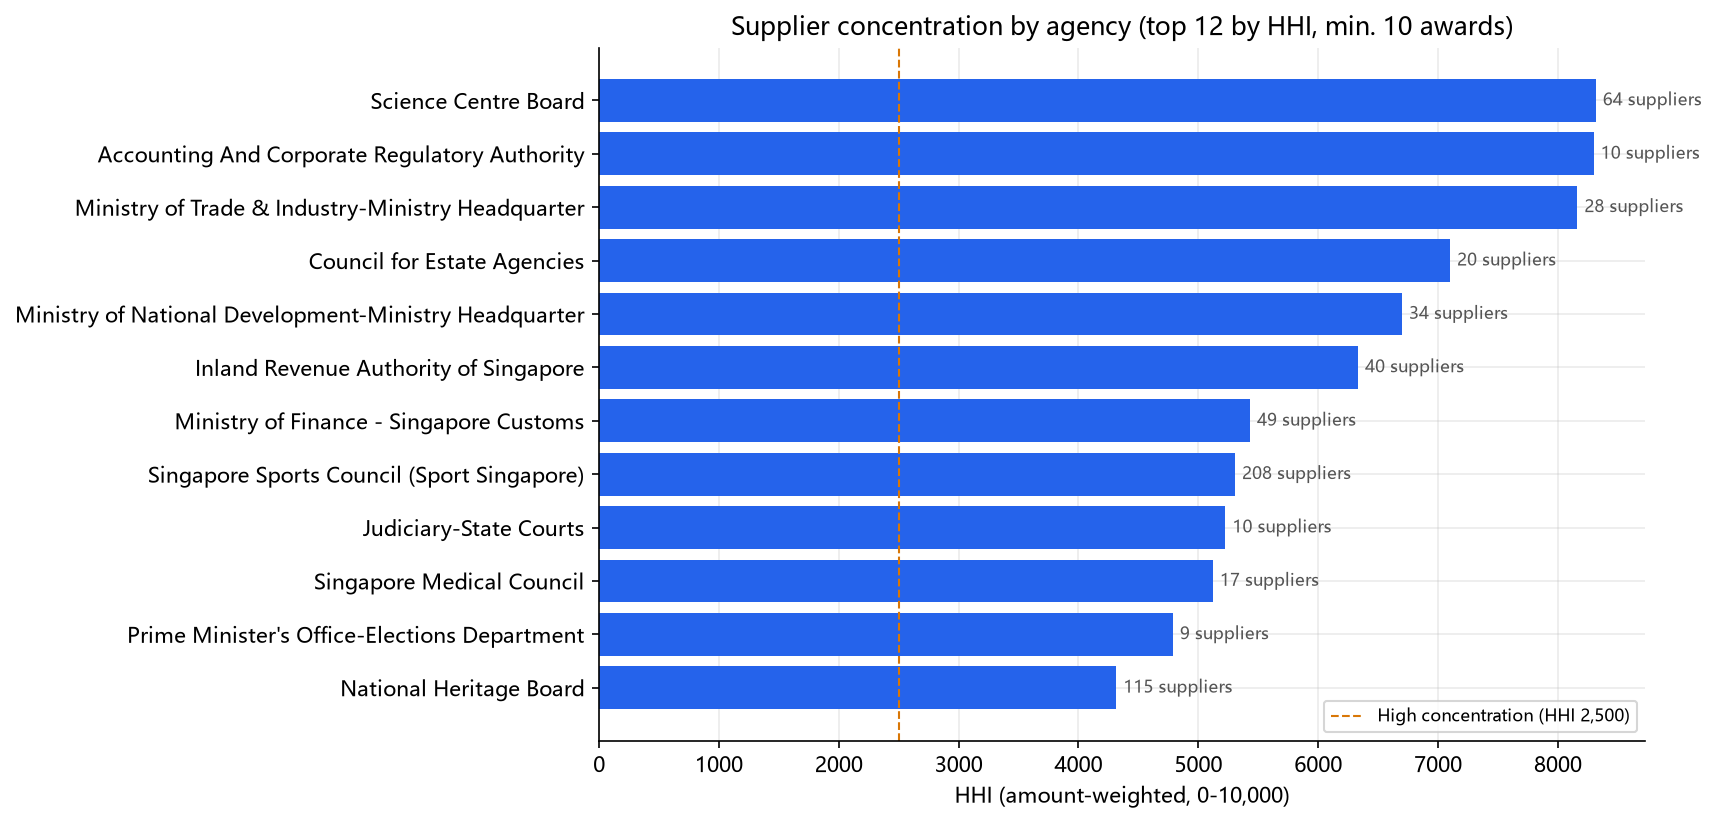

In [4]:
display(Image('../outputs/figures/concentration_by_agency.png'))

### Interpretation

- **Amount-weighted concentration is high (HHI 4,000–8,300+) for several agencies even when they have 30–200+ distinct suppliers** (e.g. Science Centre Board: 64 suppliers, HHI 8,314; Singapore Sports Council: 208 suppliers, HHI 5,305). This is not a sign of a captured or thin supplier pool — it means one or two very large contracts dominate the agency's *dollar* spend, while many smaller suppliers share the rest. Amount- and count-weighted HHI diverge exactly where this pattern holds.
- **The count-weighted top list looks completely different** (Istana, PMO divisions, State Courts) — agencies with genuinely few, tightly-scoped suppliers, which for some of these (e.g. Istana, a security-sensitive site) is a reasonable procurement pattern, not necessarily a red flag.
- **A single whole-of-government HHI is close to zero and not meaningful** — it mixes thousands of unrelated procurement categories. Concentration should always be read at the agency (or ideally category) level, never as one national figure.
- I am **not** claiming any specific agency's concentration is improper — high HHI for a specialized government agency buying specialized equipment/services can be entirely legitimate (limited qualified suppliers). This analysis flags where to *look closer* (e.g. checking whether the dominant contract was competitively tendered), not a verdict.

## 3. Amount-threshold clustering

**Rules and data scope.** MOF sets the procurement method by *estimated* value: small value purchases up to S\$6,000, quotations up to S\$90,000, tenders above S\$90,000 ([MOF](https://www.mof.gov.sg/policies/government-procurement/understanding-the-procurement-process)). The [data.gov.sg page](https://data.gov.sg/datasets/d_acde1106003906a75c3fa052592f2fcb/view) describes this dataset as the open tenders called by government agencies since FY2021. Quotations and small value purchases are not in the data, so the S\$6,000 limit cannot be tested here.

**Test.** If contracts were being kept under S\$90,000, awards would pile up just below the line. For windows of ±10%, ±5% and ±2% around S\$90,000, count awards just below and just above, and run a one-sided binomial test of "more below than above" against a 50/50 split. The threshold applies to a whole procurement, so the test is run at tender level (`awarded_amt` summed per `tender_no`, tenders with the code ETT only). The row-level count is shown alongside because the first version of this analysis used it.

**Placebo thresholds.** Awards become less frequent as amounts grow, so a symmetric window can hold more awards below the line with no clustering at all, and round numbers may attract awards through budgeting habits. The same test is run at S\$70k, 80k, 85k, 95k, 100k, 110k and 120k, where no rule applies. S\$90,000 matters only if it stands out from these.

In [5]:
tenders = aggregate_by_tender(df)
ett_tenders = tenders[tenders['procurement_type'] == 'ETT']
print(f"tenders: {len(tenders):,}; ETT: {len(ett_tenders):,}; excluded (no code): {len(tenders) - len(ett_tenders):,}")
at_or_below = (ett_tenders['awarded_amt'] <= 90000)
print(f"ETT tenders with total award <= S$90,000: {at_or_below.sum():,} of {len(ett_tenders):,} ({at_or_below.mean():.1%})")

test_thresholds = [70000, 80000, 85000, 90000, 95000, 100000, 110000, 120000]
threshold_results = pd.concat(
    [threshold_window_counts(data, test_thresholds, window_pct=w).assign(level=level)
     for level, data in [('row', df), ('tender', ett_tenders)]
     for w in (0.10, 0.05, 0.02)],
    ignore_index=True,
)
print()
print('S$90,000, row level vs tender level:')
display(threshold_results[threshold_results['threshold'] == 90000].round(3))

tenders: 11,413; ETT: 10,909; excluded (no code): 504
ETT tenders with total award <= S$90,000: 1,782 of 10,909 (16.3%)

S$90,000, row level vs tender level:


,threshold,window_pct,n_just_below,n_just_above,ratio_below_over_above,p_more_below,level
3,90000,0.10,298,239,1.247,0.006,row
11,90000,0.05,160,115,1.391,0.004,row
19,90000,0.02,82,51,1.608,0.005,row
27,90000,0.10,142,158,0.899,0.837,tender
35,90000,0.05,69,76,0.908,0.747,tender
43,90000,0.02,25,38,0.658,0.962,tender


In [6]:
print('One-sided p-value (more below than above), all thresholds:')
display(threshold_results.pivot_table(index='threshold', columns=['level', 'window_pct'], values='p_more_below').round(3))

placebo = threshold_results[threshold_results['threshold'] != 90000]
for level, g in placebo.groupby('level'):
    hits = g[g['p_more_below'] < 0.05]
    print(f"{level} level: {len(hits)} of {len(g)} placebo tests with p < 0.05 ->", hits[['threshold', 'window_pct', 'p_more_below']].round(4).values.tolist())

near = ett_tenders[(ett_tenders['awarded_amt'] >= 90000) & (ett_tenders['awarded_amt'] < 91000)]
print(f"ETT tenders in [S$90,000, S$91,000): {len(near)}, of which exactly S$90,000: {(near['awarded_amt'] == 90000).sum()}")

One-sided p-value (more below than above), all thresholds:


level         row               tender              
window_pct   0.02   0.05   0.10   0.02   0.05   0.10
threshold                                           
70000       0.171  0.732  0.727  0.570  0.989  0.989
80000       0.656  0.877  0.928  0.106  0.159  0.271
85000       0.973  0.999  0.935  0.860  0.758  0.362
90000       0.005  0.004  0.006  0.962  0.747  0.837
95000       0.623  0.952  0.174  0.653  0.966  0.897
100000      0.249  0.027  0.082  0.077  0.039  0.083
110000      0.538  0.784  0.676  0.636  0.951  0.942
120000      0.429  0.171  0.026  0.381  0.123  0.053

row level: 2 of 21 placebo tests with p < 0.05 -> [[120000.0, 0.1, 0.0262], [100000.0, 0.05, 0.0272]]
tender level: 1 of 21 placebo tests with p < 0.05 -> [[100000.0, 0.05, 0.0387]]
ETT tenders in [S$90,000, S$91,000): 29, of which exactly S$90,000: 12


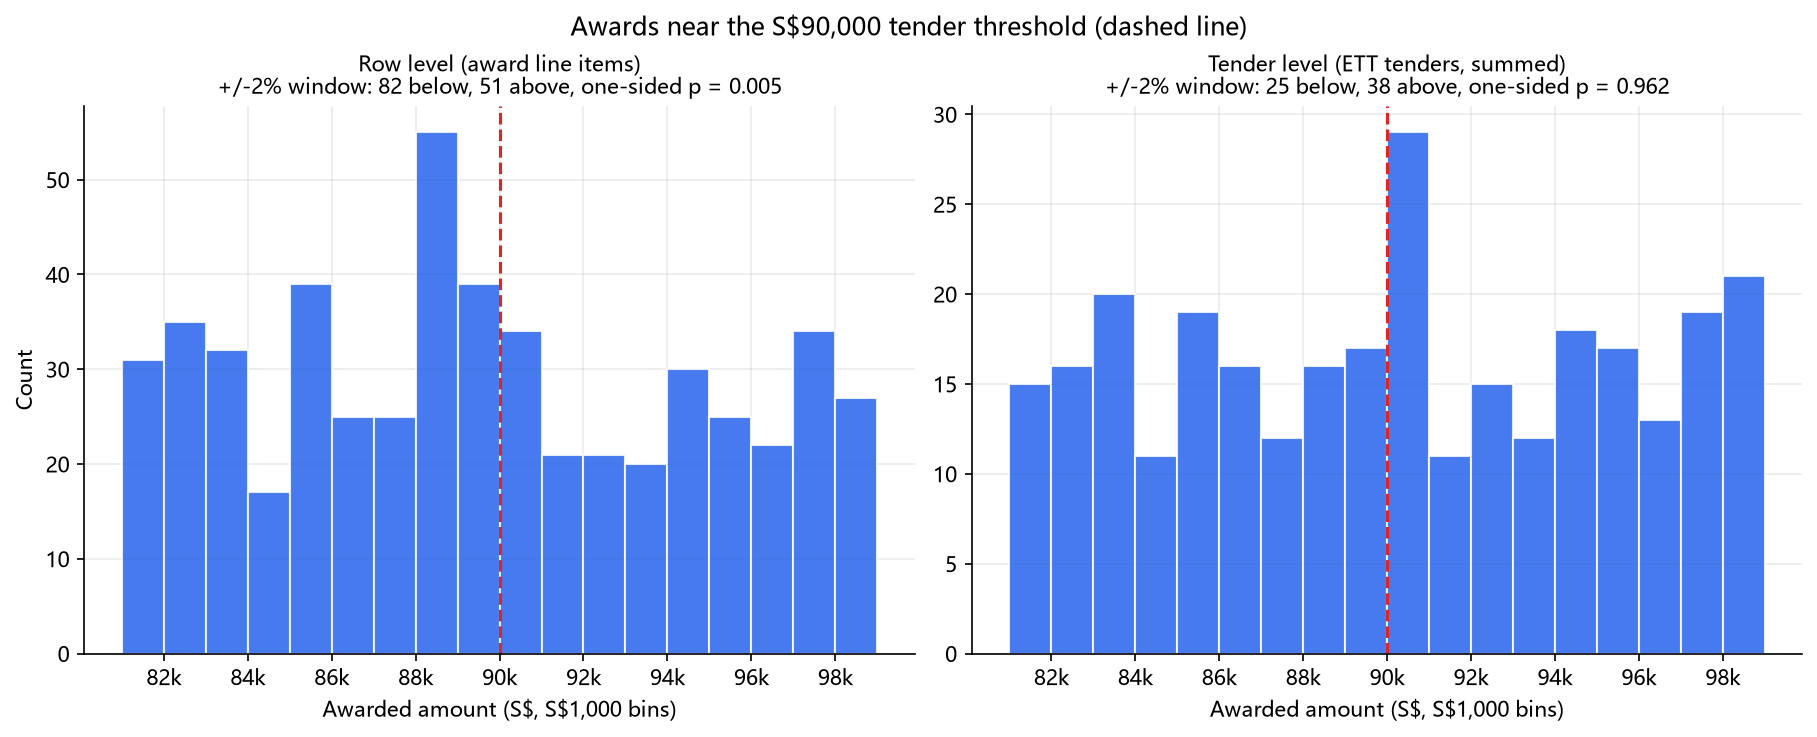

In [7]:
display(Image('../outputs/figures/threshold_zoom_90000.png'))

### Interpretation

- At tender level, which is the level the rule applies to, awards do not cluster below S\$90,000. Every window has fewer tenders just below than just above (±2%: 25 below, 38 above), and the one-sided p-values are 0.837, 0.747 and 0.962 for ±10%, ±5% and ±2%.
- The row-level count does show more awards below (±2%: 82 below, 51 above, p = 0.005). The excess disappears once rows are summed per tender, so it reflects individual line items rather than whole procurements. The first version of this analysis read the row-level result as clustering under the tender threshold; that used the wrong unit.
- Among the placebo thresholds at tender level, 1 of 21 tests has p < 0.05 (S\$100,000, ±5%). With 21 tests at the 0.05 level, about one such result is expected by chance.
- The tallest tender-level bin in the chart is S\$90,000–91,000 (29 tenders, 12 of them exactly S\$90,000). It is not tested or explained here.
- A positive result could not have shown avoidance of open tender in any case: every award in this dataset came from a tender. The rule also applies to estimated value, while the data has awarded amounts only (GST treatment not stated), and 1,782 of 10,909 ETT tenders (16.3%) were awarded at or below S\$90,000.

## 4. Benford's law

**What is tested.** Benford's law gives the expected share of each first digit (1 to 9) and each pair of first two digits (10 to 99) in data that spans several orders of magnitude and is not assigned or capped. Two measures are reported for each test. The chi-square test asks whether the deviation from Benford is larger than chance would produce. The mean absolute deviation (MAD) is the average gap between observed and expected shares. Nigrini (2012) gives bands for it: first digit close ≤ 0.006, acceptable ≤ 0.012, marginal ≤ 0.015, otherwise nonconformity; first two digits close ≤ 0.0012, acceptable ≤ 0.0018, marginal ≤ 0.0022, otherwise nonconformity.

**Scope.** The main test uses row-level awarded amounts of at least S\$10. The first-two-digit test needs values of at least 10, and a large block of awards is recorded at S\$1, S\$2 or S\$3 (counted below), which look like nominal amounts rather than prices. S\$1,000 is used as a sensitivity check and ETT tender totals as a comparison. One result without a floor is kept to show the effect of the small amounts.

In [8]:
amt = df['awarded_amt']
for label, mask in [('exactly S$1', amt == 1), ('exactly S$2', amt == 2), ('exactly S$3', amt == 3), ('below S$10, incl. zero', amt < 10)]:
    print(f"{label}: {mask.sum():,} rows ({mask.mean():.2%})")
print('S$1 rows by status:', df.loc[amt == 1, 'tender_detail_status'].value_counts().to_dict())

exactly S$1: 1,294 rows (7.26%)


exactly S$2: 205 rows (1.15%)
exactly S$3: 66 rows (0.37%)
below S$10, incl. zero: 1,768 rows (9.92%)
S$1 rows by status: {'Awarded by Items': 1214, 'Awarded to Suppliers': 75, 'Award by interface record': 5}


In [9]:
ett_totals = aggregate_by_tender(df).query("procurement_type == 'ETT'")
cases = [('row, no floor', df, 1, 0), ('row, >= S$10', df, 1, 10), ('row, >= S$10', df, 2, 10),
         ('row, >= S$1,000', df, 1, 1000), ('row, >= S$1,000', df, 2, 1000),
         ('ETT tender totals, >= S$10', ett_totals, 1, 10), ('ETT tender totals, >= S$10', ett_totals, 2, 10)]
benford_overall = pd.DataFrame([
    {'data': label, 'digits': d, **{k: v for k, v in benford_mad(data['awarded_amt'], d, floor).items() if k in ('n', 'mad', 'band', 'chi2', 'p_value')}}
    for label, data, d, floor in cases
])
benford_overall.round({'mad': 5, 'chi2': 1})

,data,digits,n,mad,band,chi2,p_value
0,"row, no floor",1,17821,0.01092,acceptable,221.7,1.694578e-43
1,"row, >= S$10",1,16057,0.00221,close,9.9,2.723688e-01
2,"row, >= S$10",2,16057,0.00086,close,178.8,5.434804e-08
3,"row, >= S$1,000",1,14894,0.00288,close,12.9,1.152548e-01
4,"row, >= S$1,000",2,14894,0.00090,close,161.7,3.882944e-06
5,"ETT tender totals, >= S$10",1,10565,0.00394,close,20.2,9.666062e-03
6,"ETT tender totals, >= S$10",2,10565,0.00105,close,154.3,2.169371e-05


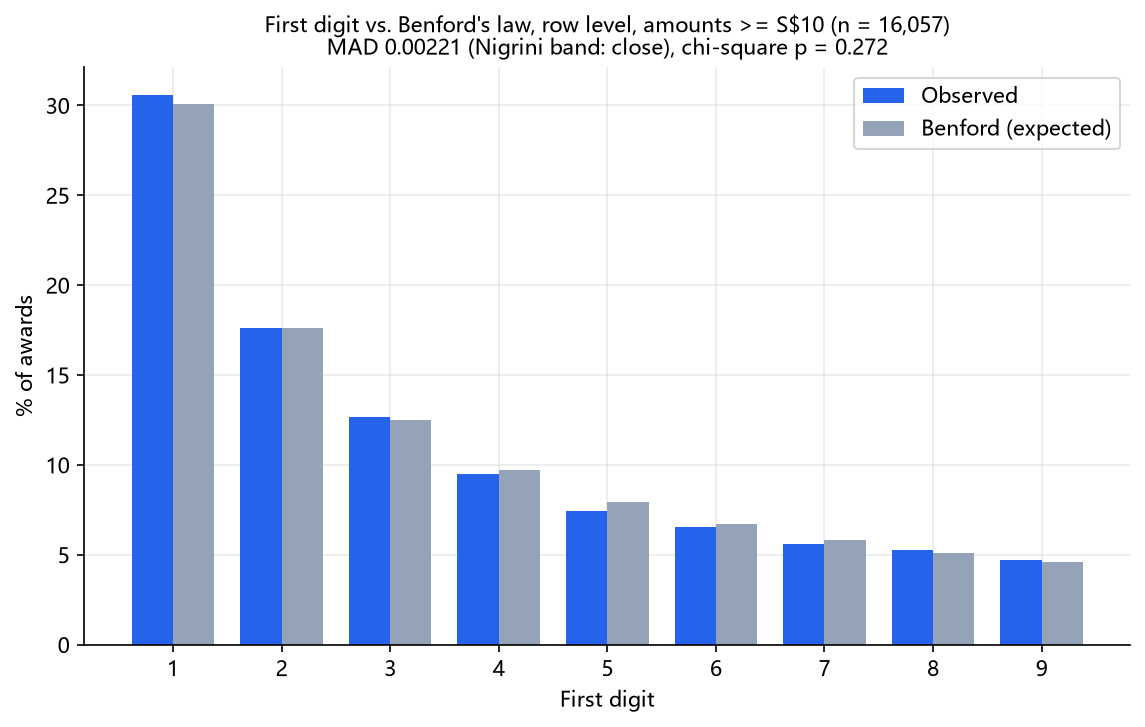

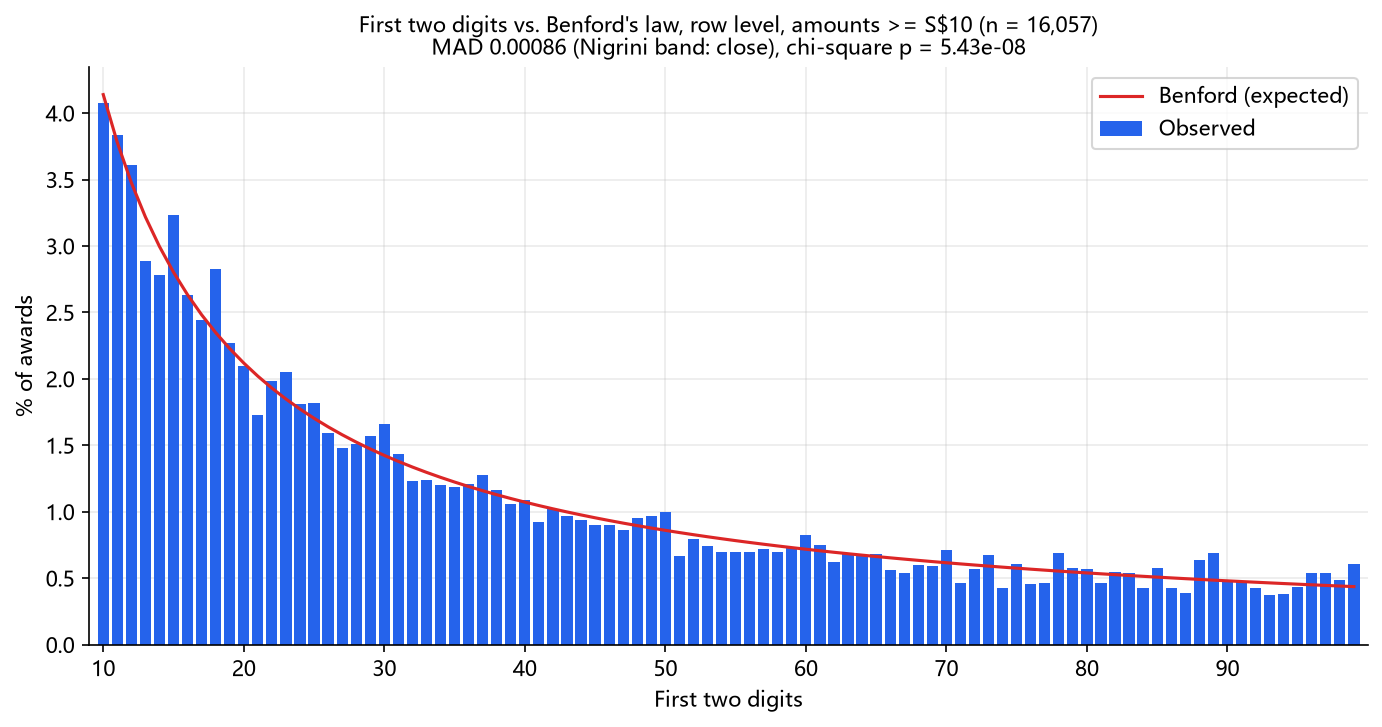

In [10]:
display(Image('../outputs/figures/benford_test.png'))
display(Image('../outputs/figures/benford_two_digits.png'))

### Why chi-square and MAD are both reported

For a deviation of the same size, the chi-square statistic grows in proportion to the number of amounts: a gap that is invisible in 500 amounts becomes "significant" in 16,000. With large samples, chi-square rejects departures too small to matter. MAD does not grow with sample size, which is why it is reported alongside. Its fixed bands have the opposite problem in small samples: random variation alone makes the MAD of a small sample large. The simulation below draws 10,000 samples of each size exactly from Benford proportions and shows how often the Nigrini bands would still label them nonconforming.

In [11]:
import numpy as np
rng = np.random.default_rng(0)
sim_rows = []
for digits in (1, 2):
    p_benford = benford_expected(digits).to_numpy()
    for n in (300, 600, 1500, 16057):
        mads = np.abs(rng.multinomial(n, p_benford, size=10000) / n - p_benford).mean(axis=1)
        sim_rows.append({'digits': digits, 'n': n, 'median_mad': np.median(mads),
                         'share_labelled_nonconformity': np.mean([nigrini_band(m, digits) == 'nonconformity' for m in mads])})
pd.DataFrame(sim_rows).round({'median_mad': 5, 'share_labelled_nonconformity': 3})

,digits,n,median_mad,share_labelled_nonconformity
0,1,300,0.01326,0.324
1,1,600,0.00940,0.034
2,1,1500,0.00596,0.000
3,1,16057,0.00182,0.000
4,2,300,0.00459,1.000
5,2,600,0.00323,1.000
6,2,1500,0.00204,0.183
7,2,16057,0.00063,0.000


### Agency level

Agencies with at least 300 amounts of S\$10 or more are tested. Agency samples are small, so each MAD is also compared with 10,000 samples of the same size drawn exactly from Benford proportions: `sim_p` is the share of those samples with a MAD at least as large, and `mad_*_if_benford` is their median. The full table is saved to `outputs/benford_by_agency.csv`. A low `sim_p` marks a digit pattern worth a closer look, not a finding about the agency.

In [12]:
benford_agencies = benford_by_agency(df)
benford_agencies.to_csv('../outputs/benford_by_agency.csv', index=False)
print(f"agencies tested: {len(benford_agencies)} (n from {benford_agencies['n'].min()} to {benford_agencies['n'].max()})")
for d in (1, 2):
    print(f"digits={d}: Nigrini nonconformity {(benford_agencies[f'band_{d}'] == 'nonconformity').sum()}, sim_p < 0.05 {(benford_agencies[f'sim_p_{d}'] < 0.05).sum()}")
print('sim_p < 0.05 on either test:', ((benford_agencies['sim_p_1'] < 0.05) | (benford_agencies['sim_p_2'] < 0.05)).sum())
benford_agencies.round(5)

agencies tested: 18 (n from 305 to 1173)
digits=1: Nigrini nonconformity 8, sim_p < 0.05 7
digits=2: Nigrini nonconformity 18, sim_p < 0.05 6
sim_p < 0.05 on either test: 8


,agency,n,mad_1,mad_1_if_benford,band_1,p_1,sim_p_1,mad_2,mad_2_if_benford,band_2,p_2,sim_p_2
0,Ministry of Foreign Affairs,483,0.04581,0.01043,nonconformity,0.00000,0.00010,0.00691,0.00361,nonconformity,0.00000,0.00010
1,Ministry of Finance - Vital,654,0.03499,0.00895,nonconformity,0.00000,0.00010,0.00566,0.00310,nonconformity,0.00000,0.00010
2,Jurong Town Corporation,331,0.02795,0.01258,nonconformity,0.00014,0.00050,0.00494,0.00437,nonconformity,0.01155,0.06409
3,Singapore Tourism Board,312,0.02716,0.01296,nonconformity,0.00326,0.00050,0.00671,0.00450,nonconformity,0.00000,0.00010
4,Ministry of Digital Development and Information,305,0.02154,0.01310,nonconformity,0.09750,0.02350,0.00585,0.00456,nonconformity,0.00007,0.00050
5,Institute of Technical Education,352,0.01791,0.01229,nonconformity,0.04792,0.07119,0.00425,0.00423,nonconformity,0.58429,0.47875
6,Ministry of Education,588,0.01547,0.00945,nonconformity,0.05761,0.02470,0.00337,0.00327,nonconformity,0.06454,0.35486
7,"Agency for Science, Technology and Research",894,0.01519,0.00765,nonconformity,0.00260,0.00140,0.00323,0.00265,nonconformity,0.00000,0.00690
8,Ministry of Health-Ministry Headquarter,317,0.01494,0.01292,marginal,0.24217,0.28687,0.00456,0.00447,nonconformity,0.56108,0.40206
9,Monetary Authority of Singapore,310,0.01334,0.01298,marginal,0.25923,0.46325,0.00470,0.00452,nonconformity,0.00223,0.31127


### Interpretation

- Across all rows of S\$10 or more (n = 16,057), both tests fall in Nigrini's "close" band: first-digit MAD 0.00221, first-two-digit MAD 0.00086. The S\$1,000 floor gives the same bands (MAD 0.00288 and 0.00090), and so do ETT tender totals (0.00394 and 0.00105).
- Chi-square disagrees on the two-digit test at the S\$10 floor (p = 5.4e-08) while accepting the first-digit test (p = 0.272). With 90 digit groups and 16,057 amounts, small departures are enough for chi-square to reject; at this size the MAD band is the more useful reading.
- Without a floor, the first-digit MAD is 0.01092 (acceptable) and chi-square p is about 1.7e-43. Removing the 1,768 amounts below S\$10, of which 1,294 are exactly S\$1, brings the first-digit MAD down to 0.00221.
- At agency level the fixed bands cannot be used on their own. In the simulation, samples of 600 amounts drawn exactly from Benford proportions fall in the two-digit nonconformity band every time, and samples of 300 fall in the first-digit nonconformity band 32.4% of the time. Agency samples here have 305 to 1,173 amounts, and all 18 agencies fall in the two-digit nonconformity band, which reflects sample size more than the agencies.
- With the size-adjusted check, 7 of 18 agencies have sim_p < 0.05 on the first digit, 6 of 18 on the first two digits, and 8 on either. At a 0.05 cut-off about one agency per test would be expected by chance (18 × 0.05 = 0.9), so these counts are above chance. They are screening signals only: in a few hundred amounts, a handful of repeated prices, standard rates or purchase types can shift digit shares, and none of these were examined here.

## 5. Supplier profile & trend

,supplier_name,total_amt,n_awards,n_agencies
0,RICH CONSTRUCTION COMPANY PTE LTD,3.539567e+09,9,4
1,KTC CIVIL ENGINEERING & CONSTRUCTION PTE LTD,2.803541e+09,19,7
2,WOH HUP PRIVATE LIMITED,2.508696e+09,6,4
3,OBAYASHI SINGAPORE PTE LTD,2.391261e+09,2,2
4,TEAMBUILD ENGINEERING & CONSTRUCTION PTE LTD,1.844377e+09,9,2
5,PENTA-OCEAN CONSTRUCTION COMPANY LIMITED,1.828634e+09,4,4
6,NEWCON BUILDERS PTE LTD,1.789420e+09,9,2
7,KAJIMA OVERSEAS ASIA SINGAPORE PTE LTD,1.735619e+09,2,2
8,BHCC CONSTRUCTION PTE LTD,1.567928e+09,6,2
9,SHANGHAI TUNNEL ENGINEERING CO SINGAPORE PTE LTD,1.426000e+09,3,2


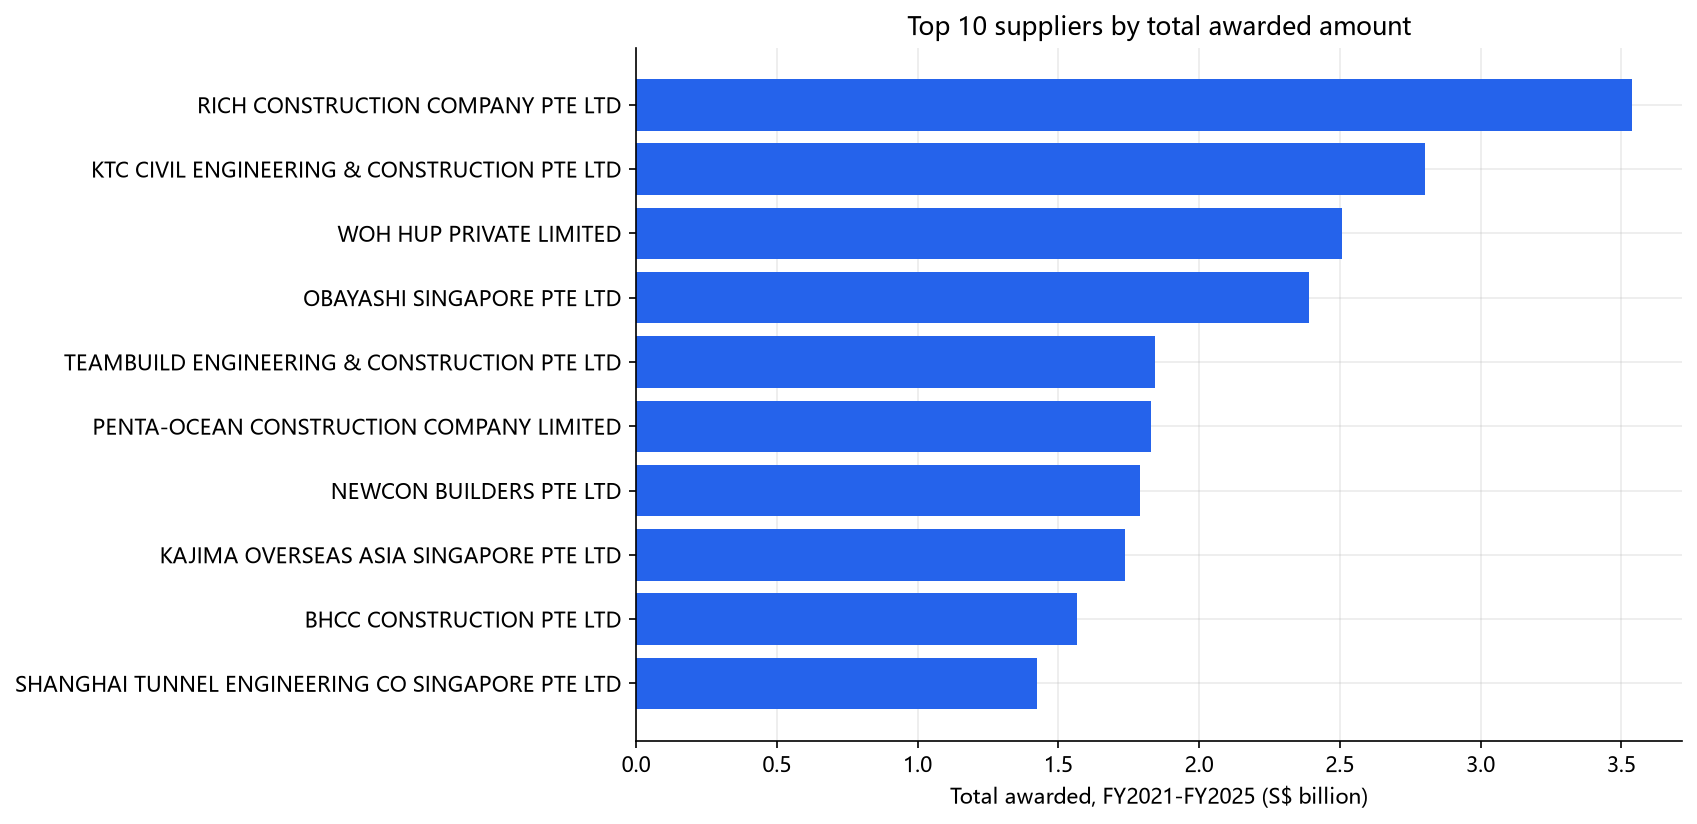

In [13]:
display(top_suppliers(df, 10))
display(Image('../outputs/figures/top_suppliers.png'))

,fiscal_year,total_amt,n_awards,n_suppliers
0,FY2021,2.418085e+10,3810,2403
1,FY2022,1.972507e+10,3333,2166
2,FY2023,2.168267e+10,3573,2284
3,FY2024,2.735110e+10,3422,2131
4,FY2025,3.088218e+10,3687,2343


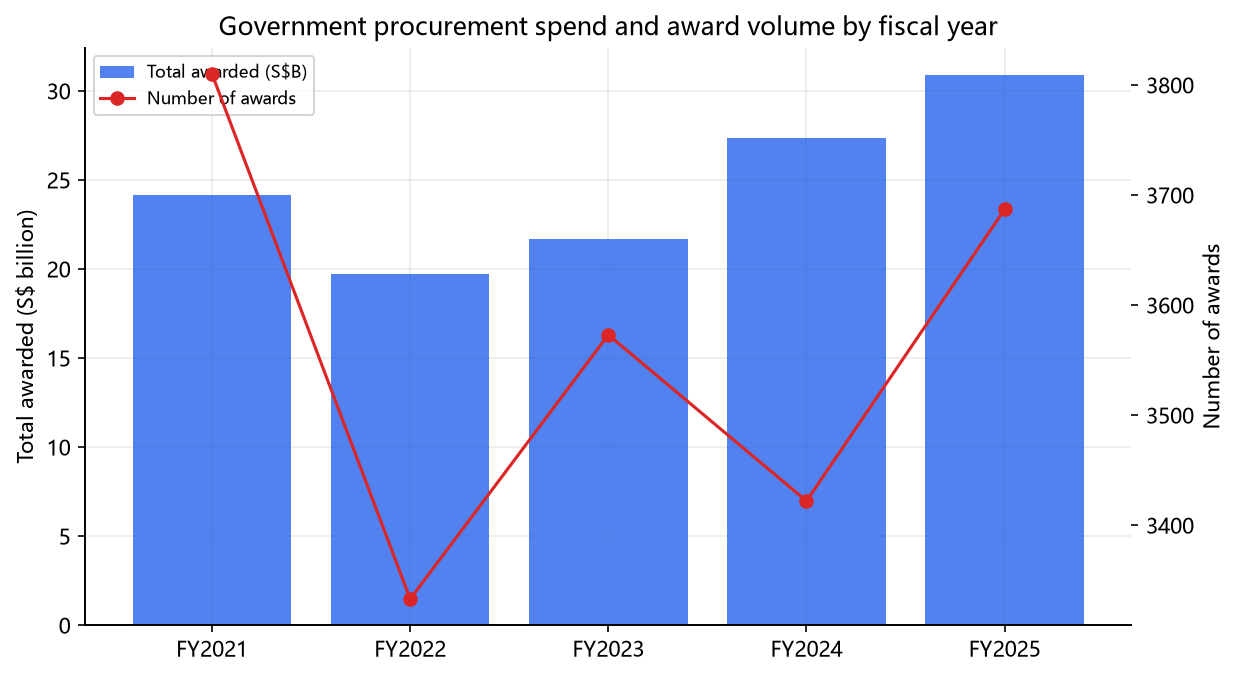

In [14]:
display(yearly_trend(df))
display(Image('../outputs/figures/yearly_trend.png'))

In [15]:
pivot = agency_year_pivot(df)
pivot['total'] = pivot.sum(axis=1)
pivot.sort_values('total', ascending=False).drop(columns='total').head(10) / 1e6  # S$ million

fiscal_year,FY2021,FY2022,FY2023,FY2024,FY2025
agency,,,,,
Land Transport Authority,10511.139286,5575.621106,6091.370731,5912.375941,6733.121960
Housing and Development Board,5659.792885,5188.081039,6655.239184,9020.817207,6846.221241
Ministry of Health-Ministry Headquarter,279.232569,1406.691195,565.154202,1918.008657,6186.562260
Ministry of Home Affairs - Ministry Headquarter 1,497.602516,1326.194696,565.596739,2690.772535,1789.065244
Public Utilities Board,1693.952645,696.144492,829.334798,1129.496532,1397.433454
Ministry of Education,548.506813,1015.040187,987.400159,1029.785318,1360.870887
National Environment Agency,981.087592,528.194311,1139.198350,654.892443,854.054344
Jurong Town Corporation,409.004661,225.386820,470.531477,1157.133132,448.707305
People's Association,188.404483,268.705777,227.544793,477.189874,257.932345


### Findings

1. The top 10 suppliers by total awarded amount are **all construction/engineering firms** (Rich Construction, KTC Civil Engineering, Woh Hup, Obayashi, Penta-Ocean, ...), each with only 2–19 awards but S$1.4B–S$3.5B in total value — consistent with a handful of large infrastructure contracts (MRT, HDB, civil works) dominating total government spend, not a sign that a few firms structurally capture government business in general.
2. Total awarded value rose from ~S$24B (FY2021) to ~S$31B (FY2025), while award *count* stayed roughly flat (~3,400–3,800/year) — spend growth is coming from bigger contracts, not more of them.
3. FY2022 had the lowest total spend (~S$19.7B) and lowest award count in the window — worth a footnote, though five fiscal years is too short a series to call this a trend rather than normal year-to-year variation (e.g. a few mega-contracts landing in adjacent fiscal years easily swings the total).
4. Agency-level spend is dominated by infrastructure/estate agencies (see pivot above) — consistent with construction firms topping the supplier list.

## Limitations

See the project [README](../README.md#limitations) for the full list. In short: this is a 5-fiscal-year rolling window (not full GeBIZ history), supplier normalization is deliberately conservative (true concentration is a lower bound, not an exact figure), and every signal here (concentration, threshold clustering, Benford deviation) is a screening flag for further audit — none of it, alone or combined, proves procurement irregularity.